<a href="https://colab.research.google.com/github/Adheeshana/FIVORA/blob/Fabric-Defect-Detection-Experiments/exp01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import zipfile
import cv2
import numpy as np
import glob
import gc
from google.colab import drive

drive.mount('/content/drive', force_remount=True)
print("✅ Drive Connected!")

zip_path = '/content/drive/MyDrive/Defects.zip'
extract_base = '/content/dataset/'

Mounted at /content/drive
✅ Drive Connected!


In [ ]:
if not os.path.exists(extract_base):
    os.makedirs(extract_base)

print("📦 Extracting dataset... Please wait.")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_base)
print("✅ Extraction Complete!\n")

📦 Extracting dataset... Please wait.
✅ Extraction Complete!



In [ ]:
ata_path = None
for root, dirs, files in os.walk(extract_base):
    if 'train' in dirs and 'valid' in dirs:
        data_path = os.path.dirname(root)
        break

if not data_path:
    print("❌ Error: '.")
else:
    classes = [d for d in os.listdir(data_path) if os.path.isdir(os.path.join(data_path, d))]
    classes = [c for c in classes if not c.startswith('.')]
    classes.sort()
    class_map = {name: i for i, name in enumerate(classes)}
    print(f"🎯 Found Classes ({len(classes)}): {classes}\n")

    IMG_SIZE = 224

🎯 Found Classes (7): ['Holes', 'Lines', 'Objects', 'Oil_Spot', 'Pinched_fabric', 'Stain', 'thread error']



In [ ]:
import os
import cv2
import numpy as np
import glob
import gc

IMG_SIZE = 224
extract_path = '/content/dataset/'

classes = [d for d in os.listdir(extract_path) if os.path.isdir(os.path.join(extract_path, d))]
classes = [c for c in classes if not c.startswith('.')]
classes.sort()
class_map = {name: i for i, name in enumerate(classes)}
print(f"🎯 Found Classes: {classes}\n")


def load_custom_yolo_data(split_name):
    images, cls_labels, bboxes = [], [], []

    for category in classes:
        img_dir = os.path.join(extract_path, category, split_name, 'images')
        lbl_dir = os.path.join(extract_path, category, split_name, 'labels')

        if not os.path.exists(img_dir):
            continue

        img_paths = glob.glob(os.path.join(img_dir, "*.*"))
        img_paths = [f for f in img_paths if f.lower().endswith(('.jpg', '.png', '.jpeg', '.webp'))]

        c_id = class_map[category]

        for img_path in img_paths:
            img = cv2.imread(img_path)
            if img is None: continue

            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            images.append(np.array(img, dtype=np.float32) / 255.0)

            base_name = os.path.splitext(os.path.basename(img_path))[0]
            txt_path = os.path.join(lbl_dir, base_name + ".txt")

            bbox = [0.5, 0.5, 0.3, 0.3]

            if os.path.exists(txt_path):
                with open(txt_path, 'r') as f:
                    lines = f.readlines()
                    if len(lines) > 0:
                        parts = lines[0].strip().split()
                        if len(parts) >= 5:

                            bbox = [float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])]

            cls_labels.append(c_id)
            bboxes.append(bbox)

    return np.array(images, dtype=np.float32), np.array(cls_labels), np.array(bboxes, dtype=np.float32)

# 3. Data පටවා ගැනීම
print("⏳ Training Data ලෝඩ් කරමින් පවතී...")
X_train, y_cls_train, y_bbox_train = load_custom_yolo_data('train')

print("⏳ Validation Data ලෝඩ් කරමින් පවතී...")
X_valid, y_cls_valid, y_bbox_valid = load_custom_yolo_data('valid')

print("⏳ Testing Data ලෝඩ් කරමින් පවතී...")
X_test, y_cls_test, y_bbox_test = load_custom_yolo_data('test')

print(f"\n🚀 Data Loading සම්පූර්ණයි!")
print(f"   Train පින්තූර: {len(X_train)}")
print(f"   Valid පින්තූර: {len(X_valid)}")
print(f"   Test පින්තූර : {len(X_test)}")

🎯 Found Classes: ['Defects']

⏳ Training Data ලෝඩ් කරමින් පවතී...
⏳ Validation Data ලෝඩ් කරමින් පවතී...
⏳ Testing Data ලෝඩ් කරමින් පවතී...

🚀 Data Loading සම්පූර්ණයි!
   Train පින්තූර: 0
   Valid පින්තූර: 0
   Test පින්තූර : 0


In [ ]:
import os
import cv2
import numpy as np
import glob
import gc

IMG_SIZE = 224
extract_base = '/content/dataset/'
data_path = None
for root, dirs, files in os.walk(extract_base):
    if 'train' in dirs and 'valid' in dirs:
        data_path = os.path.dirname(root)
        break

if not data_path:
    print("❌ Error: 'train' සහ 'valid' ෆෝල්ඩර් හොයාගන්න බැහැ!")
else:
    classes = [d for d in os.listdir(data_path) if os.path.isdir(os.path.join(data_path, d))]
    classes = [c for c in classes if not c.startswith('.')]
    classes.sort()
    class_map = {name: i for i, name in enumerate(classes)}
    print(f"🎯 Found Classes ({len(classes)}): {classes}\n")


    def load_custom_yolo_data(split_name):
        images, cls_labels, bboxes = [], [], []

        for category in classes:
            img_dir = os.path.join(data_path, category, split_name, 'images')
            lbl_dir = os.path.join(data_path, category, split_name, 'labels')

            if not os.path.exists(img_dir):
                continue

            img_paths = glob.glob(os.path.join(img_dir, "*.*"))
            img_paths = [f for f in img_paths if f.lower().endswith(('.jpg', '.png', '.jpeg', '.webp'))]

            c_id = class_map[category]

            for img_path in img_paths:
                img = cv2.imread(img_path)
                if img is None: continue

                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                images.append(np.array(img, dtype=np.float32) / 255.0)

                base_name = os.path.splitext(os.path.basename(img_path))[0]
                txt_path = os.path.join(lbl_dir, base_name + ".txt")

                bbox = [0.5, 0.5, 0.3, 0.3]

                if os.path.exists(txt_path):
                    with open(txt_path, 'r') as f:
                        lines = f.readlines()
                        if len(lines) > 0:
                            parts = lines[0].strip().split()
                            if len(parts) >= 5:
                                bbox = [float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])]

                cls_labels.append(c_id)
                bboxes.append(bbox)

        return np.array(images, dtype=np.float32), np.array(cls_labels), np.array(bboxes, dtype=np.float32)


    print("⏳ Training Data ලෝඩ් කරමින් පවතී...")
    X_train, y_cls_train, y_bbox_train = load_custom_yolo_data('train')

    print("⏳ Validation Data ලෝඩ් කරමින් පවතී...")
    X_valid, y_cls_valid, y_bbox_valid = load_custom_yolo_data('valid')

    print("⏳ Testing Data ලෝඩ් කරමින් පවතී...")
    X_test, y_cls_test, y_bbox_test = load_custom_yolo_data('test')

    print(f"\n🚀 Data Loading සම්පූර්ණයි!")
    print(f"   Train පින්තූර: {len(X_train)}")
    print(f"   Valid පින්තූර: {len(X_valid)}")
    print(f"   Test පින්තූර : {len(X_test)}")

🎯 Found Classes (7): ['Holes', 'Lines', 'Objects', 'Oil_Spot', 'Pinched_fabric', 'Stain', 'thread error']

⏳ Training Data ලෝඩ් කරමින් පවතී...
⏳ Validation Data ලෝඩ් කරමින් පවතී...
⏳ Testing Data ලෝඩ් කරමින් පවතී...

🚀 Data Loading සම්පූර්ණයි!
   Train පින්තූර: 2055
   Valid පින්තූර: 586
   Test පින්තූර : 293


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_fivora_dual_attention():
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    # Random Augmentation layers
    x = layers.RandomFlip("horizontal_and_vertical")(inputs)
    x = layers.RandomRotation(0.15)(x)
    x = layers.RandomContrast(0.2)(x)

    # 1. Base Model (MobileNetV2)
    base = tf.keras.applications.MobileNetV2(input_tensor=x, include_top=False, weights='imagenet')
    base.trainable = True # Fine-tuning සඳහා Open කිරීම
    x = base.output

    # 2. Channel Attention
    channels = x.shape[-1]
    squeeze = layers.GlobalAveragePooling2D()(x)
    excitation = layers.Dense(channels // 8, activation='relu')(squeeze)
    excitation = layers.Dense(channels, activation='sigmoid')(excitation)
    excitation = layers.Reshape((1, 1, channels))(excitation)
    x = layers.Multiply()([x, excitation])

    # 3. Spatial Attention
    s = x.shape
    x_reshaped = layers.Reshape((s[1] * s[2], s[3]))(x)
    attention = layers.MultiHeadAttention(num_heads=4, key_dim=s[3])(x_reshaped, x_reshaped)
    x_attended = layers.Add()([x_reshaped, attention])
    x_norm = layers.LayerNormalization()(x_attended)
    x_gap = layers.GlobalAveragePooling1D()(x_norm)

    # 4. Anti-Overfitting
    x_drop = layers.Dropout(0.4)(x_gap)
    x_dense = layers.Dense(128, activation='relu')(x_drop)
    x_final_drop = layers.Dropout(0.2)(x_dense)

    # 5. Output Heads (Class + Bounding Box)
    class_output = layers.Dense(len(classes), activation='softmax', name='class_output')(x_final_drop)
    bbox_output = layers.Dense(4, activation='sigmoid', name='bbox_output')(x_final_drop)

    model = models.Model(inputs=inputs, outputs=[class_output, bbox_output])

    # 6. Compile
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
        loss={'class_output': 'sparse_categorical_crossentropy', 'bbox_output': 'mse'},
        metrics={'class_output': 'accuracy', 'bbox_output': 'mse'}
    )
    return model

fivora_detector = build_fivora_dual_attention()
print("🔬 Step 3 Complete! Dual-Attention Model built.")

/tmp/ipykernel_480/3081942734.py:13: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = tf.keras.applications.MobileNetV2(input_tensor=x, include_top=False, weights='imagenet')


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
🔬 Step 3 Complete! Dual-Attention Model built.


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np
import gc

# Data Shuffle කිරීම
indices = np.arange(X_train.shape[0])
np.random.shuffle(indices)
X_shuffled = X_train[indices]
y_cls_shuffled = y_cls_train[indices]
y_bbox_shuffled = y_bbox_train[indices]

# Early Stopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

print("⏳ Training Started... Please wait.")
history = fivora_detector.fit(
    X_shuffled,
    {'class_output': y_cls_shuffled, 'bbox_output': y_bbox_shuffled},
    validation_data=(X_valid, {'class_output': y_cls_valid, 'bbox_output': y_bbox_valid}),
    epochs=30,
    batch_size=16,
    verbose=1,
    callbacks=[early_stopping]
)

fivora_detector.save('/content/drive/MyDrive/fivora_model_final.keras')
print("🎉 Model Trained & Saved to Drive!")
gc.collect()




⏳ Training Started... Please wait.
Epoch 1/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 1528s 12s/step - bbox_output_loss: 0.0596 - bbox_output_mse: 0.0595 - class_output_accuracy: 0.4852 - class_output_loss: 1.4027 - loss: 1.4661 - val_bbox_output_loss: 0.0425 - val_bbox_output_mse: 0.0425 - val_class_output_accuracy: 0.3413 - val_class_output_loss: 2.0684 - val_loss: 2.1111
Epoch 2/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 1455s 11s/step - bbox_output_loss: 0.0597 - bbox_output_mse: 0.0598 - class_output_accuracy: 0.7095 - class_output_loss: 0.8195 - loss: 0.8812 - val_bbox_output_loss: 0.0360 - val_bbox_output_mse: 0.0360 - val_class_output_accuracy: 0.3515 - val_class_output_loss: 2.1081 - val_loss: 2.1563
Epoch 3/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 1448s 11s/step - bbox_output_loss: 0.0597 - bbox_output_mse: 0.0598 - class_output_accuracy: 0.7946 - class_output_loss: 0.5963 - loss: 0.6563 - val_bbox_output_loss: 0.0405 - val_bbox_output_mse: 0.0406 - val_class_output_accuracy: 0.4232 - val_class_output_loss

10789

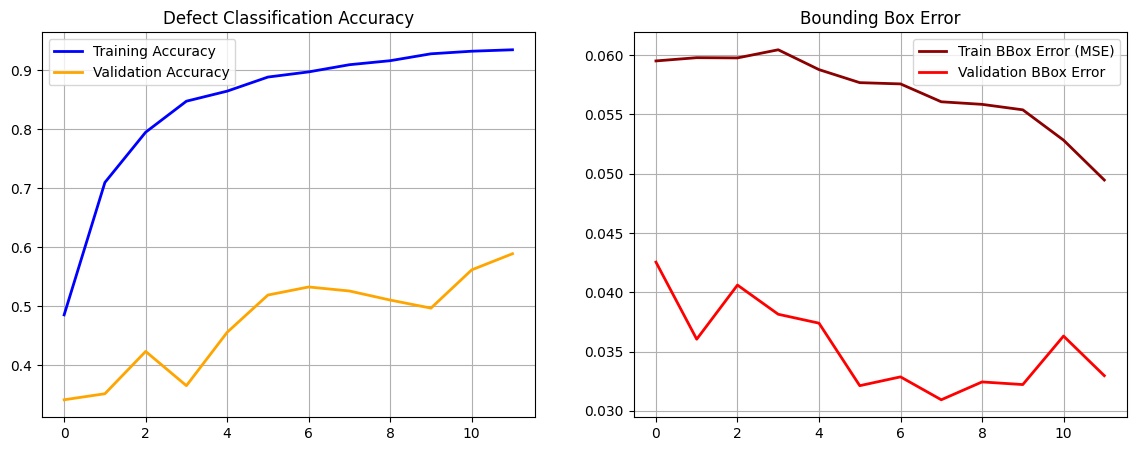

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

# Classification Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['class_output_accuracy'], label='Training Accuracy', color='blue', linewidth=2)
plt.plot(history.history['val_class_output_accuracy'], label='Validation Accuracy', color='orange', linewidth=2)
plt.title('Defect Classification Accuracy')
plt.legend()
plt.grid(True)

# Bounding Box Loss (MSE)
plt.subplot(1, 2, 2)
plt.plot(history.history['bbox_output_mse'], label='Train BBox Error (MSE)', color='darkred', linewidth=2)
plt.plot(history.history['val_bbox_output_mse'], label='Validation BBox Error', color='red', linewidth=2)
plt.title('Bounding Box Error')
plt.legend()
plt.grid(True)

plt.show()



📤 Please select ONE fabric image file to test:


Saving holeeee.jfif to holeeee.jfif


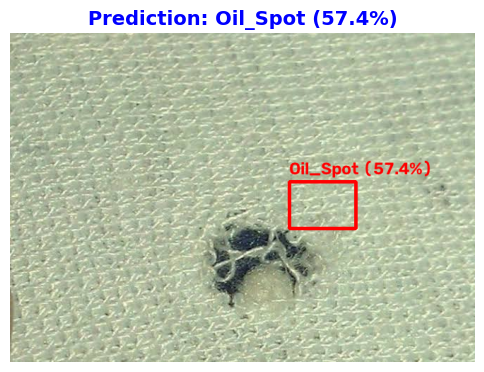

In [ ]:
from google.colab import files
import cv2

print("\n📤 Please select ONE fabric image file to test:")
uploaded = files.upload()

for filename in uploaded.keys():
    img = cv2.imread(filename)
    if img is not None:
        original_h, original_w = img.shape[:2]
        display_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Image එක Model එකට කවන විදිහට හැදීම
        img_input = np.expand_dims(cv2.resize(img, (224, 224)) / 255.0, axis=0)
        predictions = fivora_detector.predict(img_input, verbose=0)

        class_preds = predictions[0][0]
        bbox_preds = predictions[1][0]

        pred_class_id = np.argmax(class_preds)
        confidence = class_preds[pred_class_id] * 100

        # කොටුවේ Coordinates ගණනය කිරීම
        x_center, y_center = bbox_preds[0]*original_w, bbox_preds[1]*original_h
        w, h = bbox_preds[2]*original_w, bbox_preds[3]*original_h

        x_min, y_min = int(x_center - (w/2)), int(y_center - (h/2))
        x_max, y_max = int(x_center + (w/2)), int(y_center + (h/2))

        # පින්තූරයේ කොටුව සහ නම ඇඳීම
        cv2.rectangle(display_img, (x_min, y_min), (x_max, y_max), (255, 0, 0), 4)
        label = f"{classes[pred_class_id]} ({confidence:.1f}%)"
        cv2.putText(display_img, label, (x_min, max(30, y_min - 10)), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 0), 2)

        # ප්‍රතිඵලය පෙන්වීම
        plt.figure(figsize=(6, 6))
        plt.imshow(display_img)
        plt.title(f"Prediction: {label}", fontsize=14, color='blue', fontweight='bold')
        plt.axis('off')
        plt.show()

In [ ]:
print("📊 Testing Model Accuracy on Unseen Data...")

results = fivora_detector.evaluate(
    X_test,
    {'class_output': y_cls_test, 'bbox_output': y_bbox_test},
    verbose=0,
    return_dict=True
)

print("\n" + "="*40)
print(" 🎯 FINAL MODEL ACCURACY RESULTS ")
print("="*40)

# Classification Accuracy (රෝගය හරියටම අඳුරගත්ත ප්‍රතිශතය)
class_acc = results['class_output_accuracy'] * 100
print(f"✅ Defect Classification Accuracy : {class_acc:.2f}%")

# Bounding Box MSE (කොටුව අඳින තැන නිවැරදිතාවය)
bbox_mse = results['bbox_output_mse']
print(f"✅ Bounding Box Error (MSE)       : {bbox_mse:.4f}")

print("="*40)

📊 Testing Model Accuracy on Unseen Data...

 🎯 FINAL MODEL ACCURACY RESULTS 
✅ Defect Classification Accuracy : 50.51%
✅ Bounding Box Error (MSE)       : 0.0311


In [ ]:


print("⏳ ගණනය කරමින් පවතී... කරුණාකර රැඳී සිටින්න.\n")

# Test Data වලින් Accuracy එක බැලීම
results = fivora_detector.evaluate(
    X_test,
    {'class_output': y_cls_test, 'bbox_output': y_bbox_test},
    verbose=0,
    return_dict=True
)

class_acc = results['class_output_accuracy'] * 100
bbox_error = results['bbox_output_mse']

print("="*45)
print(" 🎯 TRAIN වුණු මොඩල් එකේ අවසන් ප්‍රතිඵල ")
print("="*45)
print(f"✅ රෝගය අඳුරගැනීමේ හැකියාව (Accuracy) : {class_acc:.2f}%")
print(f"✅ කොටුව අඳින නිවැරදිතාවය (BBox Error) : {bbox_error:.4f}")
print("="*45)

⏳ ගණනය කරමින් පවතී... කරුණාකර රැඳී සිටින්න.

 🎯 TRAIN වුණු මොඩල් එකේ අවසන් ප්‍රතිඵල 
✅ රෝගය අඳුරගැනීමේ හැකියාව (Accuracy) : 50.51%
✅ කොටුව අඳින නිවැරදිතාවය (BBox Error) : 0.0311



📤 Please select ONE fabric image file to test:


Saving 20260709_141923.jpg to 20260709_141923.jpg


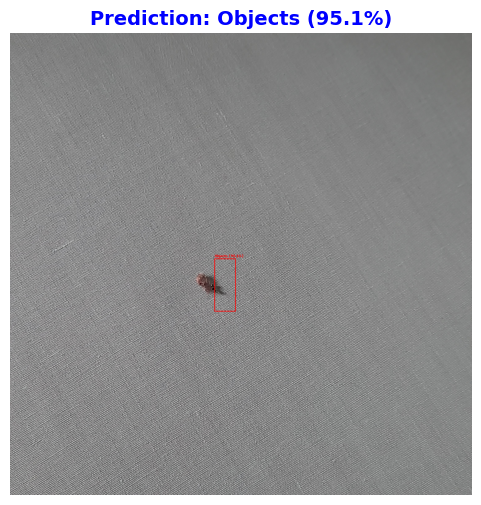

In [ ]:
from google.colab import files
import cv2

print("\n📤 Please select ONE fabric image file to test:")
uploaded = files.upload()

for filename in uploaded.keys():
    img = cv2.imread(filename)
    if img is not None:
        original_h, original_w = img.shape[:2]
        display_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Image එක Model එකට කවන විදිහට හැදීම
        img_input = np.expand_dims(cv2.resize(img, (224, 224)) / 255.0, axis=0)
        predictions = fivora_detector.predict(img_input, verbose=0)

        class_preds = predictions[0][0]
        bbox_preds = predictions[1][0]

        pred_class_id = np.argmax(class_preds)
        confidence = class_preds[pred_class_id] * 100

        # කොටුවේ Coordinates ගණනය කිරීම
        x_center, y_center = bbox_preds[0]*original_w, bbox_preds[1]*original_h
        w, h = bbox_preds[2]*original_w, bbox_preds[3]*original_h

        x_min, y_min = int(x_center - (w/2)), int(y_center - (h/2))
        x_max, y_max = int(x_center + (w/2)), int(y_center + (h/2))

        # පින්තූරයේ කොටුව සහ නම ඇඳීම
        cv2.rectangle(display_img, (x_min, y_min), (x_max, y_max), (255, 0, 0), 4)
        label = f"{classes[pred_class_id]} ({confidence:.1f}%)"
        cv2.putText(display_img, label, (x_min, max(30, y_min - 10)), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 0), 2)

        # ප්‍රතිඵලය පෙන්වීම
        plt.figure(figsize=(6, 6))
        plt.imshow(display_img)
        plt.title(f"Prediction: {label}", fontsize=14, color='blue', fontweight='bold')
        plt.axis('off')
        plt.show()


📤 Please select ONE fabric image file to test:


Saving IMG_20260717_085903.jpg to IMG_20260717_085903.jpg


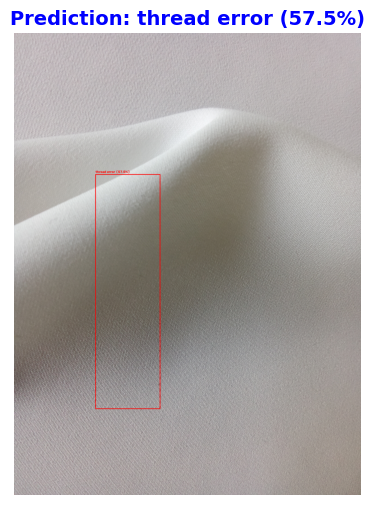

In [ ]:
from google.colab import files
import cv2

print("\n📤 Please select ONE fabric image file to test:")
uploaded = files.upload()

for filename in uploaded.keys():
    img = cv2.imread(filename)
    if img is not None:
        original_h, original_w = img.shape[:2]
        display_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Image එක Model එකට කවන විදිහට හැදීම
        img_input = np.expand_dims(cv2.resize(img, (224, 224)) / 255.0, axis=0)
        predictions = fivora_detector.predict(img_input, verbose=0)

        class_preds = predictions[0][0]
        bbox_preds = predictions[1][0]

        pred_class_id = np.argmax(class_preds)
        confidence = class_preds[pred_class_id] * 100

        # කොටුවේ Coordinates ගණනය කිරීම
        x_center, y_center = bbox_preds[0]*original_w, bbox_preds[1]*original_h
        w, h = bbox_preds[2]*original_w, bbox_preds[3]*original_h

        x_min, y_min = int(x_center - (w/2)), int(y_center - (h/2))
        x_max, y_max = int(x_center + (w/2)), int(y_center + (h/2))

        # පින්තූරයේ කොටුව සහ නම ඇඳීම
        cv2.rectangle(display_img, (x_min, y_min), (x_max, y_max), (255, 0, 0), 4)
        label = f"{classes[pred_class_id]} ({confidence:.1f}%)"
        cv2.putText(display_img, label, (x_min, max(30, y_min - 10)), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 0), 2)

        # ප්‍රතිඵලය පෙන්වීම
        plt.figure(figsize=(6, 6))
        plt.imshow(display_img)
        plt.title(f"Prediction: {label}", fontsize=14, color='blue', fontweight='bold')
        plt.axis('off')
        plt.show()


📤 Please select ONE fabric image file to test:


Saving oil spot.jpg to oil spot.jpg


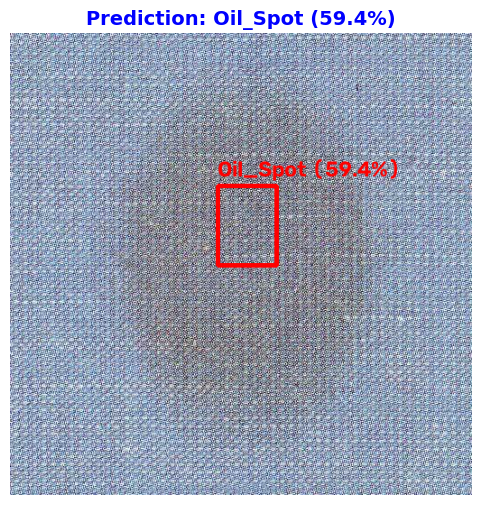

In [ ]:
from google.colab import files
import cv2

print("\n📤 Please select ONE fabric image file to test:")
uploaded = files.upload()

for filename in uploaded.keys():
    img = cv2.imread(filename)
    if img is not None:
        original_h, original_w = img.shape[:2]
        display_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Image එක Model එකට කවන විදිහට හැදීම
        img_input = np.expand_dims(cv2.resize(img, (224, 224)) / 255.0, axis=0)
        predictions = fivora_detector.predict(img_input, verbose=0)

        class_preds = predictions[0][0]
        bbox_preds = predictions[1][0]

        pred_class_id = np.argmax(class_preds)
        confidence = class_preds[pred_class_id] * 100

        # කොටුවේ Coordinates ගණනය කිරීම
        x_center, y_center = bbox_preds[0]*original_w, bbox_preds[1]*original_h
        w, h = bbox_preds[2]*original_w, bbox_preds[3]*original_h

        x_min, y_min = int(x_center - (w/2)), int(y_center - (h/2))
        x_max, y_max = int(x_center + (w/2)), int(y_center + (h/2))

        # පින්තූරයේ කොටුව සහ නම ඇඳීම
        cv2.rectangle(display_img, (x_min, y_min), (x_max, y_max), (255, 0, 0), 4)
        label = f"{classes[pred_class_id]} ({confidence:.1f}%)"
        cv2.putText(display_img, label, (x_min, max(30, y_min - 10)), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 0), 2)

        # ප්‍රතිඵලය පෙන්වීම
        plt.figure(figsize=(6, 6))
        plt.imshow(display_img)
        plt.title(f"Prediction: {label}", fontsize=14, color='blue', fontweight='bold')
        plt.axis('off')
        plt.show()


📤 Please select ONE fabric image file to test:


Saving hole.jfif to hole.jfif


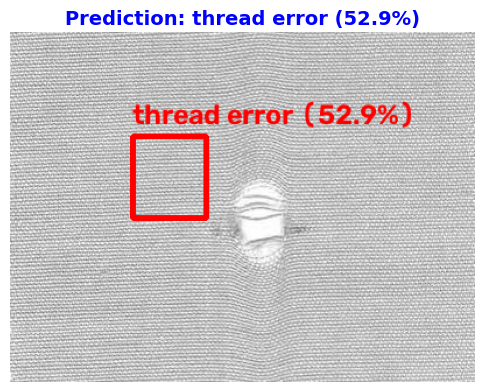

In [ ]:
from google.colab import files
import cv2

print("\n📤 Please select ONE fabric image file to test:")
uploaded = files.upload()

for filename in uploaded.keys():
    img = cv2.imread(filename)
    if img is not None:
        original_h, original_w = img.shape[:2]
        display_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Image එක Model එකට කවන විදිහට හැදීම
        img_input = np.expand_dims(cv2.resize(img, (224, 224)) / 255.0, axis=0)
        predictions = fivora_detector.predict(img_input, verbose=0)

        class_preds = predictions[0][0]
        bbox_preds = predictions[1][0]

        pred_class_id = np.argmax(class_preds)
        confidence = class_preds[pred_class_id] * 100

        # කොටුවේ Coordinates ගණනය කිරීම
        x_center, y_center = bbox_preds[0]*original_w, bbox_preds[1]*original_h
        w, h = bbox_preds[2]*original_w, bbox_preds[3]*original_h

        x_min, y_min = int(x_center - (w/2)), int(y_center - (h/2))
        x_max, y_max = int(x_center + (w/2)), int(y_center + (h/2))

        # පින්තූරයේ කොටුව සහ නම ඇඳීම
        cv2.rectangle(display_img, (x_min, y_min), (x_max, y_max), (255, 0, 0), 4)
        label = f"{classes[pred_class_id]} ({confidence:.1f}%)"
        cv2.putText(display_img, label, (x_min, max(30, y_min - 10)), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 0), 2)

        # ප්‍රතිඵලය පෙන්වීම
        plt.figure(figsize=(6, 6))
        plt.imshow(display_img)
        plt.title(f"Prediction: {label}", fontsize=14, color='blue', fontweight='bold')
        plt.axis('off')
        plt.show()


📤 Please select ONE fabric image file to test:


Saving neeee.jfif to neeee.jfif


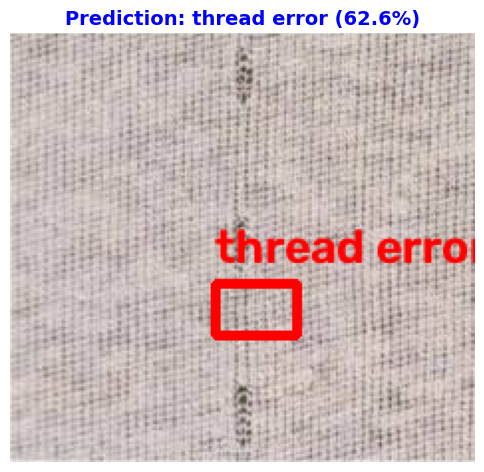

In [ ]:
from google.colab import files
import cv2

print("\n📤 Please select ONE fabric image file to test:")
uploaded = files.upload()

for filename in uploaded.keys():
    img = cv2.imread(filename)
    if img is not None:
        original_h, original_w = img.shape[:2]
        display_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Image එක Model එකට කවන විදිහට හැදීම
        img_input = np.expand_dims(cv2.resize(img, (224, 224)) / 255.0, axis=0)
        predictions = fivora_detector.predict(img_input, verbose=0)

        class_preds = predictions[0][0]
        bbox_preds = predictions[1][0]

        pred_class_id = np.argmax(class_preds)
        confidence = class_preds[pred_class_id] * 100

        # කොටුවේ Coordinates ගණනය කිරීම
        x_center, y_center = bbox_preds[0]*original_w, bbox_preds[1]*original_h
        w, h = bbox_preds[2]*original_w, bbox_preds[3]*original_h

        x_min, y_min = int(x_center - (w/2)), int(y_center - (h/2))
        x_max, y_max = int(x_center + (w/2)), int(y_center + (h/2))

        # පින්තූරයේ කොටුව සහ නම ඇඳීම
        cv2.rectangle(display_img, (x_min, y_min), (x_max, y_max), (255, 0, 0), 4)
        label = f"{classes[pred_class_id]} ({confidence:.1f}%)"
        cv2.putText(display_img, label, (x_min, max(30, y_min - 10)), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 0), 2)

        # ප්‍රතිඵලය පෙන්වීම
        plt.figure(figsize=(6, 6))
        plt.imshow(display_img)
        plt.title(f"Prediction: {label}", fontsize=14, color='blue', fontweight='bold')
        plt.axis('off')
        plt.show()